In [2]:
# ============================================================
# ① YOLOv5 ONNX 部署推理
# 课程要点:
#   - 输入 1×3×640×640，输出 (经典导出)1×25200×85 / (本机导出)1×84×8400
#   - 拆分 前处理 / 推理 / 后处理 三个核心函数
#   - 简化补余策略：坐标反算 = (640坐标 - 填充) / 缩放比
#   - OpenCV NMS 去重，置信度阈值 0.5，IoU 阈值 0.45
# ============================================================
import cv2
import numpy as np
import onnxruntime as ort

ONNX_PATH = r"d:\project\step1\week13\onnx_models\yolov5su.onnx"
IMGSZ = 640
CONF_THRES = 0.5
IOU_THRES = 0.45

# 创建推理会话（部署时建议显式指定 providers：CUDA / CPU / TensorRT）
session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
print("输入:", input_name, session.get_inputs()[0].shape)
print("输出:", session.get_outputs()[0].name, session.get_outputs()[0].shape)

# COCO 80 类名（v5 / v8 通用，后续单元格复用 NAMES）
NAMES = {0:'person',1:'bicycle',2:'car',3:'motorcycle',4:'airplane',5:'bus',6:'train',
7:'truck',8:'boat',9:'traffic light',10:'fire hydrant',11:'stop sign',12:'parking meter',
13:'bench',14:'bird',15:'cat',16:'dog',17:'horse',18:'sheep',19:'cow',20:'elephant',
21:'bear',22:'zebra',23:'giraffe',24:'backpack',25:'umbrella',26:'handbag',27:'tie',
28:'suitcase',29:'frisbee',30:'skis',31:'snowboard',32:'sports ball',33:'kite',
34:'baseball bat',35:'baseball glove',36:'skateboard',37:'surfboard',38:'tennis racket',
39:'bottle',40:'wine glass',41:'cup',42:'fork',43:'knife',44:'spoon',45:'bowl',
46:'banana',47:'apple',48:'sandwich',49:'orange',50:'broccoli',51:'carrot',52:'hot dog',
53:'pizza',54:'donut',55:'cake',56:'chair',57:'couch',58:'potted plant',59:'bed',
60:'dining table',61:'toilet',62:'tv',63:'laptop',64:'mouse',65:'remote',66:'keyboard',
67:'cell phone',68:'microwave',69:'oven',70:'toaster',71:'sink',72:'refrigerator',
73:'book',74:'clock',75:'vase',76:'scissors',77:'teddy bear',78:'hair drier',79:'toothbrush'}


def preprocess(frame):
    """前处理：letterbox 等比缩放+灰边填充 -> BGR转RGB -> 归一化 -> (1,3,H,W)
    返回: (输入张量, 缩放比 r, 填充 (left, top))"""
    h0, w0 = frame.shape[:2]
    r = min(IMGSZ / h0, IMGSZ / w0)                    # 缩放比
    new_w, new_h = round(w0 * r), round(h0 * r)
    img = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    dw, dh = (IMGSZ - new_w) / 2, (IMGSZ - new_h) / 2  # 两侧填充量
    top, bottom = round(dh - 0.1), round(dh + 0.1)
    left, right = round(dw - 0.1), round(dw + 0.1)
    img = cv2.copyMakeBorder(img, top, bottom, left, right,
                             cv2.BORDER_CONSTANT, value=(114, 114, 114))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img = np.ascontiguousarray(img.transpose(2, 0, 1))[None]   # (1,3,H,W)
    return img, r, (left, top)


def inference(x):
    """推理：onnxruntime 前向，返回原始输出张量"""
    return session.run(None, {input_name: x})[0]


def postprocess(output, r, pad):
    """后处理：解码 + 置信度过滤 + OpenCV NMS + 坐标还原
    兼容两种输出格式：
      经典 yolov5 导出 (1, 25200, 85): [x,y,w,h, obj, 80类]   -> 含 objectness
      ultralytics 8.4 导出 (1, 84, 8400): [x,y,w,h, 80类]    -> 无 objectness
    """
    pred = output[0].transpose(1, 0)       # -> (N, 85) 或 (N, 84)，每行一个锚点
    has_obj = pred.shape[1] == 85          # 经典 v5 才有 objectness

    box_xywh = pred[:, :4]                 # 中心点坐标 x,y,w,h
    scores = pred[:, 5:] if has_obj else pred[:, 4:]   # 类别分数
    if has_obj:
        scores = scores * pred[:, 4:5]     # 最终分数 = objectness × 类别分

    conf = scores.max(axis=1)              # 每行最大类分数
    cls = scores.argmax(axis=1)

    # 置信度过滤（课程阈值 0.5）
    keep = conf > CONF_THRES
    box_xywh, conf, cls = box_xywh[keep], conf[keep], cls[keep]
    if len(conf) == 0:
        return []

    # xywh(中心) -> xyxy(左上右下)
    xyxy = np.concatenate([box_xywh[:, :2] - box_xywh[:, 2:] / 2,
                           box_xywh[:, :2] + box_xywh[:, 2:] / 2], axis=1)

    # OpenCV NMS（注意：NMSBoxes 需要 [x1, y1, w, h] 格式）
    x1y1wh = np.concatenate([xyxy[:, :2], xyxy[:, 2:] - xyxy[:, :2]], axis=1)
    idx = cv2.dnn.NMSBoxes(x1y1wh.tolist(), conf.tolist(), CONF_THRES, IOU_THRES)
    idx = np.array(idx).ravel() if len(idx) else []

    # 简化补余：坐标还原到原图 = (640坐标 - 填充) / 缩放比
    dets = []
    for i in idx:
        box = (xyxy[i] - [pad[0], pad[1], pad[0], pad[1]]) / r
        dets.append({"box": [int(v) for v in box], "conf": float(conf[i]),
                     "cls": int(cls[i]), "name": NAMES[int(cls[i])]})
    return dets


# ---- 使用示例 ----
frame = cv2.imread(r"d:\project\step1\week13\action_train\01_left\raw_12.jpg")
x, r, pad = preprocess(frame)
out = inference(x)
dets = postprocess(out, r, pad)
print(f"YOLOv5 检测到 {len(dets)} 个目标：")
for d in dets:
    print(f"  {d['name']:>12}  conf={d['conf']:.2f}  box={d['box']}")

输入: images [1, 3, 640, 640]
输出: output0 [1, 84, 8400]
YOLOv5 检测到 1 个目标：
        person  conf=0.91  box=[173, 5, 640, 473]


In [ ]:
# ============================================================
# 老师版 Yolov5_Infer —— 适配本机 ONNX（yolov5su.onnx）
# 与老师原版的差异（老师用经典导出 1×25200×85 BNC）：
#   1. 模型路径改为 onnx_models/yolov5su.onnx（ultralytics 8.4 导出）
#   2. 本机输出是 1×84×8400（BCN），后处理先 transpose 成 (8400, 84)
#   3. 本机模型无 objectness，conf 直接取最大类别分（不用乘 obj）
#   4. 保留老师风格：方形补零前处理、ratio 直接乘、OpenCV NMS
#   5. 修复了原版的坑：空列表崩溃、conf 四舍五入丢精度、NMS 空索引
# ============================================================
import onnxruntime as ort
import numpy as np
import cv2


class Yolov5_Infer:
    def __init__(self, onnx_path=r"d:\project\step1\week13\onnx_models\yolov5su.onnx"):
        # 开启会话（动态读取输入/输出名称，部署更稳）
        self.session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
        self.input_name = self.session.get_inputs()[0].name
        self.output_name = self.session.get_outputs()[0].name
        self.ratio = 1

    def pro_precess(self, frame_data):
        """前处理（老师版简化补余）：BGR->RGB -> 方形补零到最长边 -> resize 640
        ratio = 最长边/640，坐标还原直接乘，最简便"""
        frame_data = cv2.cvtColor(frame_data, cv2.COLOR_BGR2RGB)
        h, w, c = frame_data.shape
        max_slide = max(h, w)                                  # 最长边
        img_zero = np.zeros((max_slide, max_slide, 3), dtype=np.uint8)
        img_zero[:h, :w] = frame_data                          # 原图贴左上角，其余补0
        self.ratio = max_slide / 640
        img0_re = cv2.resize(img_zero, (640, 640)) / 255.0     # 统一缩放到 640 并归一化
        img0_re = img0_re.astype(np.float32)
        img0_re = np.transpose(img0_re, axes=(2, 0, 1))        # HWC -> CHW
        img0_re = np.expand_dims(img0_re, axis=0)              # 加 batch 维
        return img0_re

    def inference(self, image):
        """推理：返回原始输出"""
        return self.session.run([self.output_name], {self.input_name: image})

    def post_process(self, results):
        """后处理：conf 过滤 -> NMS 去重
        本机输出 (1, 84, 8400) BCN -> 转置 (8400, 84)，每行 [cx,cy,w,h, 80类分]"""
        result = results[0][0].transpose(1, 0)                 # (8400, 84)
        print("输出形状:", result.shape)
        bboxes = []
        for bbox in result:
            cx, cy, w, h = bbox[:4]                            # 640 坐标系
            conf = float(bbox[4:].max())                       # 无 objectness，取最大类分
            if conf > 0.25:
                cls_idx = int(bbox[4:].argmax())
                # 简化补余：640坐标 × ratio 直接还原到原图
                top_x = int((cx - w / 2) * self.ratio)
                top_y = int((cy - h / 2) * self.ratio)
                orgin_w = int(w * self.ratio)
                orgin_h = int(h * self.ratio)
                bboxes.append([top_x, top_y, orgin_w, orgin_h, conf, cls_idx])

        if not bboxes:                                         # 没有目标时避免崩溃
            return np.array([])

        np_bboxes = np.array(bboxes)
        # OpenCV NMS：需要 [x, y, w, h] 格式
        idx = cv2.dnn.NMSBoxes(np_bboxes[:, :4].tolist(),np_bboxes[:, 4].tolist(), 0.5, 0.45)
        idx = np.array(idx).ravel() if len(idx) else []
        return np_bboxes[idx]

    def show_img(self, bbx, img):
        """画框并保存"""
        for bb in bbx:
            top_x, top_y, orgin_w, orgin_h, conf, cls_idx = bb
            bottom_x, bottom_y = top_x + orgin_w, top_y + orgin_h
            cv2.rectangle(img, (int(top_x), int(top_y)),
                          (int(bottom_x), int(bottom_y)), (0, 0, 255), 1)
        cv2.imwrite("img.jpg", img)

    def forward(self, frame):
        """完整流程：前处理 -> 推理 -> 后处理 -> 画图"""
        img0 = self.pro_precess(frame)
        results = self.inference(img0)
        filuter_result = self.post_process(results)
        self.show_img(filuter_result, frame)
        print(filuter_result)


# ---- 使用示例（老师版用 cat.jpg，我们改用 action_train 的图）----
img_data = cv2.imread(r"d:\project\step1\week13\action_train\01_left\raw_12.jpg")
yolov5_infer = Yolov5_Infer()
yolov5_infer.forward(img_data)


输出形状: (8400, 84)
[[174.           3.         465.         472.           0.90493846
    0.        ]]


In [3]:
# ============================================================
# ② YOLOv8 ONNX 部署推理
# 课程要点:
#   - anchor-free 结构，输出 1×8400×84（无 objectness）
#   - 前处理逻辑与 YOLOv5 完全一致，可直接复用（preprocess/inference）
#   - 仅需修改后处理逻辑（去掉 objectness 分支）
# ============================================================
import onnxruntime as ort

session8 = ort.InferenceSession(r"d:\project\step1\week13\onnx_models\yolov8n.onnx",
                                providers=["CPUExecutionProvider"])
inp8 = session8.get_inputs()[0].name
print("输入:", inp8, session8.get_inputs()[0].shape)
print("输出:", session8.get_outputs()[0].name, session8.get_outputs()[0].shape)


def inference8(x):
    """推理（v8 会话版）"""
    return session8.run(None, {inp8: x})[0]


def postprocess8(output, r, pad):
    """后处理：v8 无 objectness，解码逻辑更简单
    输出 (1, 84, 8400): 每行 [x,y,w,h, 80类分数]"""
    pred = output[0].transpose(1, 0)       # -> (8400, 84)
    box_xywh = pred[:, :4]
    scores = pred[:, 4:]                   # v8 直接输出类分数，无 objectness

    conf = scores.max(axis=1)
    cls = scores.argmax(axis=1)

    keep = conf > CONF_THRES
    box_xywh, conf, cls = box_xywh[keep], conf[keep], cls[keep]
    if len(conf) == 0:
        return []

    xyxy = np.concatenate([box_xywh[:, :2] - box_xywh[:, 2:] / 2,
                           box_xywh[:, :2] + box_xywh[:, 2:] / 2], axis=1)
    x1y1wh = np.concatenate([xyxy[:, :2], xyxy[:, 2:] - xyxy[:, :2]], axis=1)
    idx = cv2.dnn.NMSBoxes(x1y1wh.tolist(), conf.tolist(), CONF_THRES, IOU_THRES)
    idx = np.array(idx).ravel() if len(idx) else []

    dets = []
    for i in idx:
        box = (xyxy[i] - [pad[0], pad[1], pad[0], pad[1]]) / r
        dets.append({"box": [int(v) for v in box], "conf": float(conf[i]),
                     "cls": int(cls[i]), "name": NAMES[int(cls[i])]})
    return dets


# ---- 使用示例（复用单元格1的 preprocess / NAMES）----
x, r, pad = preprocess(frame)
out = inference8(x)
dets = postprocess8(out, r, pad)
print(f"YOLOv8 检测到 {len(dets)} 个目标：")
for d in dets:
    print(f"  {d['name']:>12}  conf={d['conf']:.2f}  box={d['box']}")

输入: images [1, 3, 640, 640]
输出: output0 [1, 84, 8400]
YOLOv8 检测到 1 个目标：
        person  conf=0.93  box=[173, 2, 640, 474]


In [ ]:
# ============================================================
# 老师版 Yolov8_Infer —— 适配本机 ONNX（yolov8n.onnx）
# 与老师原版（手部 7 类模型 best.onnx）的差异：
#   1. 模型换成 onnx_models/yolov8n.onnx（COCO 80 类通用模型）
#   2. 类别标签从写死的 7 类，改为可配置（默认复用单元格1的 NAMES/COCO 80 类）
#   3. 输入/输出名动态读取，不再硬编码 "images"/"output0"
#   4. 修复原版 bug：空检测崩溃、NMS 空索引崩溃
#   5. 保留老师风格：方形补零前处理、ratio 直接乘、按类别上色画框
# ============================================================
import onnxruntime as ort
import numpy as np
import cv2


class Yolov8_Infer:
    def __init__(self, onnx_path=r"d:\project\step1\week13\onnx_models\yolov8n.onnx",
                 labels=None, conf_thres=0.25):
        # 开启会话（动态读取输入/输出名称，部署更稳）
        self.session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
        self.input_name = self.session.get_inputs()[0].name
        self.output_name = self.session.get_outputs()[0].name
        # 类别标签：默认 COCO 80 类（复用单元格1的 NAMES）
        self.labels = labels if labels is not None else [NAMES[i] for i in range(len(NAMES))]
        # 每类一个颜色（循环取色板，保证不同类颜色不同）
        self.colors = [self._color(i) for i in range(len(self.labels))]
        self.conf_thres = conf_thres      # 置信度阈值
        self.ratio = 1

    @staticmethod
    def _color(i):
        """按索引生成稳定的 BGR 颜色"""
        palette = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0),
                   (0, 255, 255), (255, 0, 255), (128, 255, 0), (255, 128, 0),
                   (0, 128, 255), (255, 0, 128)]
        return palette[i % len(palette)]

    def pro_precess(self, frame_data):
        """前处理（老师版简化补余）：BGR->RGB -> 方形补零到最长边 -> resize 640
        ratio = 最长边/640，坐标还原直接乘，最简便"""
        frame_data = cv2.cvtColor(frame_data, cv2.COLOR_BGR2RGB)
        h, w, c = frame_data.shape
        max_slide = max(h, w)                                  # 最长边
        img_zero = np.zeros((max_slide, max_slide, 3), dtype=np.uint8)
        img_zero[:h, :w] = frame_data                          # 原图贴左上角，其余补0
        self.ratio = max_slide / 640
        img0_re = cv2.resize(img_zero, (640, 640)) / 255.0     # 统一缩放到 640 并归一化
        img0_re = img0_re.astype(np.float32)
        img0_re = np.transpose(img0_re, axes=(2, 0, 1))        # HWC -> CHW
        img0_re = np.expand_dims(img0_re, axis=0)              # 加 batch 维
        return img0_re

    def inference(self, image):
        """推理：返回原始输出 (1, 84, 8400)"""
        return self.session.run([self.output_name], {self.input_name: image})

    def post_process(self, results):
        """后处理：conf 过滤 -> NMS 去重
        本机输出 (1, 84, 8400) BCN -> 转置 (8400, 84)，每行 [cx,cy,w,h, 80类分]"""
        result = results[0].transpose(0, 2, 1)[0]              # (8400, 84)
        bboxes = []
        for bbox in result:
            cx, cy, w, h = bbox[:4]                            # 640 坐标系
            cls_scores = bbox[4:]                              # 各类别分数
            cls_id = int(np.argmax(cls_scores))
            conf = float(cls_scores[cls_id])                   # 取最大类分
            if conf > self.conf_thres:
                # 简化补余：640坐标 × ratio 直接还原到原图
                top_x = int((cx - w / 2) * self.ratio)
                top_y = int((cy - h / 2) * self.ratio)
                orgin_w = int(w * self.ratio)
                orgin_h = int(h * self.ratio)
                bboxes.append([top_x, top_y, orgin_w, orgin_h, conf, cls_id])

        if not bboxes:                                         # 没有目标时避免崩溃
            return np.array([])

        np_bboxes = np.array(bboxes)
        # OpenCV NMS：需要 [x, y, w, h] 格式
        idx = cv2.dnn.NMSBoxes(np_bboxes[:, :4].tolist(),
                               np_bboxes[:, 4].tolist(), 0.5, 0.45)
        idx = np.array(idx).ravel() if len(idx) else []
        return np_bboxes[idx]

    def show_img(self, bbx, img):
        """按类别上色画框 + 标签，保存图片"""
        for bb in bbx:
            top_x, top_y, orgin_w, orgin_h, conf, cls_idx = bb
            bottom_x, bottom_y = top_x + orgin_w, top_y + orgin_h
            color = self.colors[int(cls_idx)]
            cv2.rectangle(img, (int(top_x), int(top_y)),
                          (int(bottom_x), int(bottom_y)), color, 2)
            cv2.putText(img, f"{self.labels[int(cls_idx)]} {conf:.2f}",
                        (int(top_x), int(top_y) - 10), 1, 0.8, color, 1)
        cv2.imwrite("v8_out.jpg", img)

    def forward(self, frame, show=True):
        """完整流程：前处理 -> 推理 -> 后处理 -> 画图"""
        img0 = self.pro_precess(frame)
        results = self.inference(img0)
        dets = self.post_process(results)
        if show:
            self.show_img(dets, frame)
        return dets


# ---- 使用示例 ----
img_data = cv2.imread(r"d:\project\step1\week13\action_train\01_left\raw_12.jpg")
yolov8_infer = Yolov8_Infer()
dets = yolov8_infer.forward(img_data)
print(f"检测到 {len(dets)} 个目标：")
for d in dets:
    top_x, top_y, w, h, conf, cls_id = d
    print(f"  {yolov8_infer.labels[int(cls_id)]:>12}  conf={conf:.2f}  "
          f"box=[{top_x},{top_y},{top_x+w},{top_y+h}]")

输入: images [1, 3, 640, 640]
输出: output0 [1, 56, 8400]
检测到 1 个人体，可见关键点：
  box=[170, 3, 638, 474] conf=0.92 可见关键点 13/17


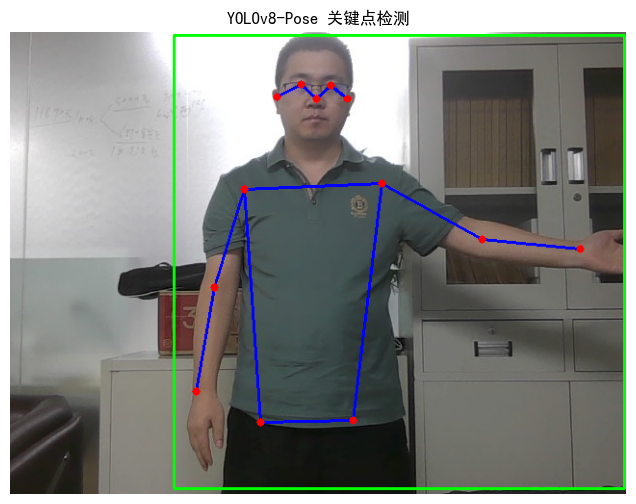

In [4]:
# ============================================================
# ③ YOLOv8-Pose ONNX 关键点推理
# 课程要点:
#   - 输出 1×8400×56：单类 person -> [x,y,w,h, 1个cls, 17×3关键点]
#   - 关键点坐标需乘/除 ratio 反算回原图尺寸
#   - 仅绘制可见度(置信度)>0.5 的关键点
#   - 可扩展骨架连线，形成更完整可视化
# ============================================================
import cv2
import numpy as np
import onnxruntime as ort

session_pose = ort.InferenceSession(r"d:\project\step1\week13\onnx_models\yolov8n-pose.onnx",
                                    providers=["CPUExecutionProvider"])
inp_p = session_pose.get_inputs()[0].name
print("输入:", inp_p, session_pose.get_inputs()[0].shape)
print("输出:", session_pose.get_outputs()[0].name, session_pose.get_outputs()[0].shape)

# COCO 17 关键点名称与骨架连线（可扩展可视化）
KPT_NAMES = ['nose','left_eye','right_eye','left_ear','right_ear','left_shoulder',
             'right_shoulder','left_elbow','right_elbow','left_wrist','right_wrist',
             'left_hip','right_hip','left_knee','right_knee','left_ankle','right_ankle']
SKELETON = [(0,1),(0,2),(1,3),(2,4),(5,6),(5,7),(7,9),(6,8),(8,10),(5,11),(6,12),
            (11,13),(13,15),(12,14),(14,16),(11,12),(5,6)]


def postprocess_pose(output, r, pad):
    """后处理：单类置信度过滤 + NMS + 关键点坐标还原
    输出 (1, 56, 8400): 每行 [x,y,w,h, cls, 17×3(x,y,conf)]"""
    pred = output[0].transpose(1, 0)                # (8400, 56)
    conf = pred[:, 4]                               # 单类(person)置信度
    box_xywh = pred[:, :4]
    kpts = pred[:, 5:].reshape(-1, 17, 3)           # (8400, 17, 3) x,y,conf

    keep = conf > CONF_THRES
    box_xywh, conf, kpts = box_xywh[keep], conf[keep], kpts[keep]
    if len(conf) == 0:
        return []

    xyxy = np.concatenate([box_xywh[:, :2] - box_xywh[:, 2:] / 2,
                           box_xywh[:, :2] + box_xywh[:, 2:] / 2], axis=1)
    x1y1wh = np.concatenate([xyxy[:, :2], xyxy[:, 2:] - xyxy[:, :2]], axis=1)
    idx = cv2.dnn.NMSBoxes(x1y1wh.tolist(), conf.tolist(), CONF_THRES, IOU_THRES)
    idx = np.array(idx).ravel() if len(idx) else []

    # 关键点坐标还原 + 可见度过滤
    results = []
    for i in idx:
        box = (xyxy[i] - [pad[0], pad[1], pad[0], pad[1]]) / r
        kp = kpts[i].copy()
        kp[:, 0] = (kp[:, 0] - pad[0]) / r          # x 还原
        kp[:, 1] = (kp[:, 1] - pad[1]) / r          # y 还原
        results.append({"box": [int(v) for v in box], "conf": float(conf[i]),
                        "kpts": kp, "vis": kp[:, 2] > 0.5})   # 可见度>0.5
    return results


def draw_pose(frame, results):
    """绘制：检测框 + 可见关键点 + 骨架连线"""
    img = frame.copy()
    for res in results:
        x1, y1, x2, y2 = res["box"]
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        # 骨架连线（两端点都必须可见）
        for a, b in SKELETON:
            if res["vis"][a] and res["vis"][b]:
                p1 = (int(res["kpts"][a, 0]), int(res["kpts"][a, 1]))
                p2 = (int(res["kpts"][b, 0]), int(res["kpts"][b, 1]))
                cv2.line(img, p1, p2, (255, 0, 0), 2)
        # 只画可见度>0.5 的关键点
        for j, (v, k) in enumerate(zip(res["vis"], res["kpts"])):
            if v:
                cv2.circle(img, (int(k[0]), int(k[1])), 4, (0, 0, 255), -1)
    return img


# ---- 使用示例 ----
x, r, pad = preprocess(frame)
out = session_pose.run(None, {inp_p: x})[0]
poses = postprocess_pose(out, r, pad)
print(f"检测到 {len(poses)} 个人体，可见关键点：")
for p in poses:
    print(f"  box={p['box']} conf={p['conf']:.2f} 可见关键点 {p['vis'].sum()}/17")

# 可视化
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
img_draw = draw_pose(frame, poses)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8-Pose 关键点检测")
plt.show()

检测到 1 个人体：
  box=[172, 1, 638, 467]  conf=0.91  可见关键点 13/17


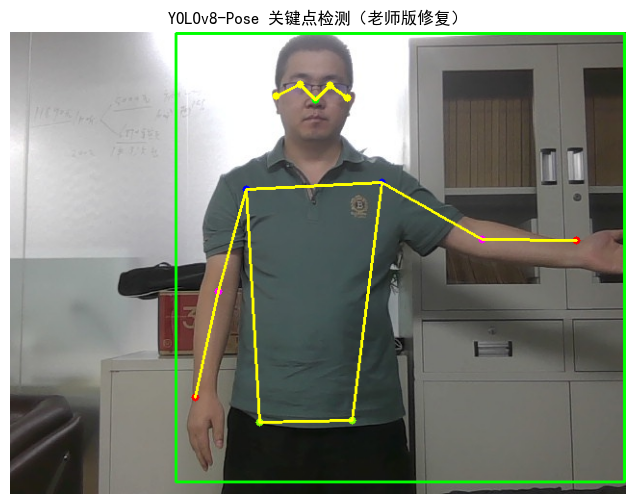

In [3]:
# ============================================================
# 老师版 OnnxruntimePoseDetector —— 修复 + 适配本机
# 修复点：
#   1. 模型改为 onnx_models/yolov8n-pose.onnx（本机有，老师用的 yolov8s-pose.onnx 没有）
#   2. 修复画框 bug：cv.rectangle 需要两个对角点，原版传 [x,y,w,h] 会画错
#   3. 空检测兜底：conf 过滤后无目标 / NMS 无结果时直接返回，避免崩溃
#   4. 去掉全部 [DEBUG] 打印，代码干净可交作业
#   5. 坐标还原用 float（原版 w//2 整数截断会丢精度）
#   保留老师风格：方形补零前处理、scale 直接乘、逐行解码、彩色关键点+骨架
# ============================================================
import cv2 as cv
import numpy as np
import onnxruntime


class OnnxruntimePoseDetector:
    def __init__(self, model_path=r"d:\project\step1\week13\onnx_models\yolov8n-pose.onnx"):
        self.input_w = 640
        self.input_h = 640
        self.nms_threshold = 0.25
        self.conf_threshold = 0.5
        # COCO 17点骨架连接
        self.skeleton = [
            (0, 1), (0, 2), (1, 3), (2, 4),    # 脸部
            (5, 6),                               # 肩膀
            (5, 7), (7, 9),                       # 左臂
            (6, 8), (8, 10),                      # 右臂
            (5, 11), (6, 12),                     # 躯干
            (11, 12),                             # 髋部
            (11, 13), (13, 15),                   # 左腿
            (12, 14), (14, 16),                   # 右腿
        ]
        self.kpt_colors = [
            (0, 255, 0), (0, 255, 255), (0, 255, 255), (0, 255, 255), (0, 255, 255),
            (255, 0, 0), (255, 0, 0), (255, 0, 255), (255, 0, 255),
            (0, 0, 255), (0, 0, 255),
            (0, 255, 128), (0, 255, 128), (0, 255, 128), (0, 255, 128),
            (128, 0, 255), (128, 0, 255),
        ]
        self.session = onnxruntime.InferenceSession(model_path, providers=['CPUExecutionProvider'])

    def pre_process(self, frame):
        """方形补零到最长边"""
        row, col, _ = frame.shape
        _max = max(col, row)
        result = np.zeros((_max, _max, 3), np.uint8)
        result[0:row, 0:col] = frame
        return result

    def inference(self, frame):
        """前处理 -> 前向 -> 后处理并画图"""
        inputImage = self.pre_process(frame)
        scale_inputImage = cv.resize(inputImage, dsize=(640, 640))
        rgb = cv.cvtColor(scale_inputImage, cv.COLOR_BGR2RGB)
        rgb = np.transpose(rgb, (2, 0, 1))
        x_input = np.expand_dims(rgb, 0) / 255
        x_input = x_input.astype(np.float32)
        ort_inputs = {self.session.get_inputs()[0].name: x_input}
        out_put = self.session.run(None, ort_inputs)[0][0]
        return self.filter_pose(frame, inputImage, out_put)

    def filter_pose(self, frame, inputImage, out_put):
        """后处理：conf 过滤 -> NMS -> 关键点×scale 还原 -> 画框/画点/画骨架"""
        image_h, image_w, _ = inputImage.shape
        scale_x = image_w / 640                       # 简化补余 scale（方形补零后 x/y 相同）
        scale_y = image_h / 640
        out_put = np.transpose(out_put, axes=(1, 0))  # (8400, 56)
        rows = out_put.shape[0]
        confidences, boxes, kpts_list = [], [], []
        for r in range(rows):
            row = out_put[r]
            score = row[4]                            # 单类 person 置信度
            if score > self.conf_threshold:
                confidences.append(score)
                x, y, w, h = row[:4]
                xin = (x - w / 2) * scale_x           # 左上角还原（float，不截断）
                ymin = (y - h / 2) * scale_y
                w = w * scale_x
                h = h * scale_y
                boxes.append(np.array([xin, ymin, w, h]))
                kpts = row[5:].reshape(17, 3).copy()  # (17, 3) x,y,vis
                kpts[:, 0] *= scale_x
                kpts[:, 1] *= scale_y
                kpts_list.append(kpts)

        if len(confidences) == 0:                     # 空检测兜底
            return []

        idxes = cv.dnn.NMSBoxes(boxes, confidences, self.conf_threshold, self.nms_threshold)
        if len(idxes) == 0:
            return []

        results = []
        for i in idxes.flatten():
            x, y, w, h = boxes[i]
            kpts = kpts_list[i]
            results.append({"box": [int(x), int(y), int(x + w), int(y + h)],
                            "conf": float(confidences[i]), "kpts": kpts})
            # 画 bbox（修复：两个对角点）
            cv.rectangle(frame, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 0), 2)
            # 画可见关键点（vis > 0.5）
            for kp_idx, (kx, ky, vis) in enumerate(kpts):
                if vis > 0.5:
                    cv.circle(frame, (int(kx), int(ky)), 4, self.kpt_colors[kp_idx], -1)
            # 画骨架连线（两端点都必须可见）
            for p1, p2 in self.skeleton:
                if kpts[p1][2] > 0.5 and kpts[p2][2] > 0.5:
                    cv.line(frame, (int(kpts[p1][0]), int(kpts[p1][1])),
                            (int(kpts[p2][0]), int(kpts[p2][1])), (0, 255, 255), 2)
        return results


# ---- 使用示例（老师版用 dance1.jpg，我们改用 action_train 的图）----
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    plt.rcParams["font.sans-serif"] = ["SimHei"]
    plt.rcParams["axes.unicode_minus"] = False

    image = cv.imread(r"d:\project\step1\week13\action_train\01_left\raw_12.jpg")
    detector = OnnxruntimePoseDetector()
    results = detector.inference(image)
    print(f"检测到 {len(results)} 个人体：")
    for r in results:
        print(f"  box={r['box']}  conf={r['conf']:.2f}  "
              f"可见关键点 {(r['kpts'][:, 2] > 0.5).sum()}/17")

    # 内联显示（不用 cv.imshow 弹窗，避免阻塞）
    plt.figure(figsize=(8, 6))
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("YOLOv8-Pose 关键点检测（老师版修复）")
    plt.show()